In [1]:
from huggingface_hub import login
# Une petite fenêtre va s'ouvrir pour coller ton token
login()

In [2]:
!pip install -U transformers accelerate torch seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 118.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoModelForCausalLM, AutoTokenizer


In [4]:
model_id = "meta-llama/Llama-3.2-1B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    output_attentions=True,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [5]:
!pip install -q transformers accelerate torch matplotlib seaborn sentencepiece


In [7]:
long_context= """
Down the Rabbit-Hole
Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure of
making a daisy-chain would be worth the trouble of getting up and
picking the daisies, when suddenly a White Rabbit with pink eyes ran
close by her.

There was nothing so _very_ remarkable in that; nor did Alice think it
so _very_ much out of the way to hear the Rabbit say to itself, “Oh
dear! Oh dear! I shall be late!” (when she thought it over afterwards,
it occurred to her that she ought to have wondered at this, but at the
time it all seemed quite natural); but when the Rabbit actually _took a
watch out of its waistcoat-pocket_, and looked at it, and then hurried
on, Alice started to her feet, for it flashed across her mind that she
had never before seen a rabbit with either a waistcoat-pocket, or a
watch to take out of it, and burning with curiosity, she ran across the
field after it, and fortunately was just in time to see it pop down a
large rabbit-hole under the hedge.

In another moment down went Alice after it, never once considering how
in the world she was to get out again.

The rabbit-hole went straight on like a tunnel for some way, and then
dipped suddenly down, so suddenly that Alice had not a moment to think
about stopping herself before she found herself falling down a very
deep well.

Either the well was very deep, or she fell very slowly, for she had
plenty of time as she went down to look about her and to wonder what
was going to happen next. First, she tried to look down and make out
what she was coming to, but it was too dark to see anything; then she
looked at the sides of the well, and noticed that they were filled with
cupboards and book-shelves; here and there she saw maps and pictures
hung upon pegs. She took down a jar from one of the shelves as she
passed; it was labelled “ORANGE MARMALADE”, but to her great
disappointment it was empty: she did not like to drop the jar for fear
of killing somebody underneath, so managed to put it into one of the
cupboards as she fell past it.

“Well!” thought Alice to herself, “after such a fall as this, I shall
think nothing of tumbling down stairs! How brave they’ll all think me
at home! Why, I wouldn’t say anything about it, even if I fell off the
top of the house!” (Which was very likely true.)

Down, down, down. Would the fall _never_ come to an end? “I wonder how
many miles I’ve fallen by this time?” she said aloud. “I must be
getting somewhere near the centre of the earth. Let me see: that would
be four thousand miles down, I think—” (for, you see, Alice had learnt
several things of this sort in her lessons in the schoolroom, and
though this was not a _very_ good opportunity for showing off her
knowledge, as there was no one to listen to her, still it was good
practice to say it over) “—yes, that’s about the right distance—but
then I wonder what Latitude or Longitude I’ve got to?” (Alice had no
idea what Latitude was, or Longitude either, but thought they were nice
grand words to say.)

Presently she began again. “I wonder if I shall fall right _through_
the earth! How funny it’ll seem to come out among the people that walk
with their heads downward! The Antipathies, I think—” (she was rather
glad there _was_ no one listening, this time, as it didn’t sound at all
the right word) “—but I shall have to ask them what the name of the
country is, you know. Please, Ma’am, is this New Zealand or Australia?”
(and she tried to curtsey as she spoke—fancy _curtseying_ as you’re
falling through the air! Do you think you could manage it?) “And what
an ignorant little girl she’ll think me for asking! No, it’ll never do
to ask: perhaps I shall see it written up somewhere.”

Down, down, down. There was nothing else to do, so Alice soon began
talking again. “Dinah’ll miss me very much to-night, I should think!”
(Dinah was the cat.) “I hope they’ll remember her saucer of milk at
tea-time. Dinah my dear! I wish you were down here with me! There are
no mice in the air, I’m afraid, but you might catch a bat, and that’s
very like a mouse, you know. But do cats eat bats, I wonder?” And here
Alice began to get rather sleepy, and went on saying to herself, in a
dreamy sort of way, “Do cats eat bats? Do cats eat bats?” and
sometimes, “Do bats eat cats?” for, you see, as she couldn’t answer
either question, it didn’t much matter which way she put it. She felt
that she was dozing off, and had just begun to dream that she was
walking hand in hand with Dinah, and saying to her very earnestly,
“Now, Dinah, tell me the truth: did you ever eat a bat?” when suddenly,
thump! thump! down she came upon a heap of sticks and dry leaves, and
the fall was over.

Alice was not a bit hurt, and she jumped up on to her feet in a moment:
she looked up, but it was all dark overhead; before her was another
long passage, and the White Rabbit was still in sight, hurrying down
it. There was not a moment to be lost: away went Alice like the wind,
and was just in time to hear it say, as it turned a corner, “Oh my ears
and whiskers, how late it’s getting!” She was close behind it when she
turned the corner, but the Rabbit was no longer to be seen: she found
herself in a long, low hall, which was lit up by a row of lamps hanging
from the roof.

There were doors all round the hall, but they were all locked; and when
Alice had been all the way down one side and up the other, trying every
door, she walked sadly down the middle, wondering how she was ever to
get out again.

Suddenly she came upon a little three-legged table, all made of solid
glass; there was nothing on it except a tiny golden key, and Alice’s
first thought was that it might belong to one of the doors of the hall;
but, alas! either the locks were too large, or the key was too small,
but at any rate it would not open any of them. However, on the second
time round, she came upon a low curtain she had not noticed before, and
behind it was a little door about fifteen inches high: she tried the
little golden key in the lock, and to her great delight it fitted!

Alice opened the door and found that it led into a small passage, not
much larger than a rat-hole: she knelt down and looked along the
passage into the loveliest garden you ever saw. How she longed to get
out of that dark hall, and wander about among those beds of bright
flowers and those cool fountains, but she could not even get her head
through the doorway; “and even if my head would go through,” thought
poor Alice, “it would be of very little use without my shoulders. Oh,
how I wish I could shut up like a telescope! I think I could, if I only
knew how to begin.” For, you see, so many out-of-the-way things had
happened lately, that Alice had begun to think that very few things
indeed were really impossible.

There seemed to be no use in waiting by the little door, so she went
back to the table, half hoping she might find another key on it, or at
any rate a book of rules for shutting people up like telescopes: this
time she found a little bottle on it, (“which certainly was not here
before,” said Alice,) and round the neck of the bottle was a paper
label, with the words “DRINK ME,” beautifully printed on it in large
letters.

It was all very well to say “Drink me,” but the wise little Alice was
not going to do _that_ in a hurry. “No, I’ll look first,” she said,
“and see whether it’s marked ‘_poison_’ or not”; for she had read
several nice little histories about children who had got burnt, and
eaten up by wild beasts and other unpleasant things, all because they
_would_ not remember the simple rules their friends had taught them:
such as, that a red-hot poker will burn you if you hold it too long;
and that if you cut your finger _very_ deeply with a knife, it usually
bleeds; and she had never forgotten that, if you drink much from a
bottle marked “poison,” it is almost certain to disagree with you,
sooner or later.

However, this bottle was _not_ marked “poison,” so Alice ventured to
taste it, and finding it very nice, (it had, in fact, a sort of mixed
flavour of cherry-tart, custard, pine-apple, roast turkey, toffee, and
hot buttered toast,) she very soon finished it off.

“What a curious feeling!” said Alice; “I must be shutting up like a
telescope.”

And so it was indeed: she was now only ten inches high, and her face
brightened up at the thought that she was now the right size for going
through the little door into that lovely garden. First, however, she
waited for a few minutes to see if she was going to shrink any further:
she felt a little nervous about this; “for it might end, you know,”
said Alice to herself, “in my going out altogether, like a candle. I
wonder what I should be like then?” And she tried to fancy what the
flame of a candle is like after the candle is blown out, for she could
not remember ever having seen such a thing.

After a while, finding that nothing more happened, she decided on going
into the garden at once; but, alas for poor Alice! when she got to the
door, she found she had forgotten the little golden key, and when she
went back to the table for it, she found she could not possibly reach
it: she could see it quite plainly through the glass, and she tried her
best to climb up one of the legs of the table, but it was too slippery;
and when she had tired herself out with trying, the poor little thing
sat down and cried.

“Come, there’s no use in crying like that!” said Alice to herself,
rather sharply; “I advise you to leave off this minute!” She generally
gave herself very good advice, (though she very seldom followed it),
and sometimes she scolded herself so severely as to bring tears into
her eyes; and once she remembered trying to box her own ears for having
cheated herself in a game of croquet she was playing against herself,
for this curious child was very fond of pretending to be two people.
“But it’s no use now,” thought poor Alice, “to pretend to be two
people! Why, there’s hardly enough of me left to make _one_ respectable
person!”

Soon her eye fell on a little glass box that was lying under the table:
she opened it, and found in it a very small cake, on which the words
“EAT ME” were beautifully marked in currants. “Well, I’ll eat it,” said
Alice, “and if it makes me grow larger, I can reach the key; and if it
makes me grow smaller, I can creep under the door; so either way I’ll
get into the garden, and I don’t care which happens!”

She ate a little bit, and said anxiously to herself, “Which way? Which
way?”, holding her hand on the top of her head to feel which way it was
growing, and she was quite surprised to find that she remained the same
size: to be sure, this generally happens when one eats cake, but Alice
had got so much into the way of expecting nothing but out-of-the-way
things to happen, that it seemed quite dull and stupid for life to go
on in the common way.

So she set to work, and very soon finished off the cake.


CHAPTER II.
The Pool of Tears


“Curiouser and curiouser!” cried Alice (she was so much surprised, that
for the moment she quite forgot how to speak good English); “now I’m
opening out like the largest telescope that ever was! Good-bye, feet!”
(for when she looked down at her feet, they seemed to be almost out of
sight, they were getting so far off). “Oh, my poor little feet, I
wonder who will put on your shoes and stockings for you now, dears? I’m
sure _I_ shan’t be able! I shall be a great deal too far off to trouble
myself about you: you must manage the best way you can;—but I must be
kind to them,” thought Alice, “or perhaps they won’t walk the way I
want to go! Let me see: I’ll give them a new pair of boots every
Christmas.”

And she went on planning to herself how she would manage it. “They must
go by the carrier,” she thought; “and how funny it’ll seem, sending
presents to one’s own feet! And how odd the directions will look!

     _Alice’s Right Foot, Esq., Hearthrug, near the Fender,_ (_with
     Alice’s love_).

Oh dear, what nonsense I’m talking!”

Just then her head struck against the roof of the hall: in fact she was
now more than nine feet high, and she at once took up the little golden
key and hurried off to the garden door.

Poor Alice! It was as much as she could do, lying down on one side, to
look through into the garden with one eye; but to get through was more
hopeless than ever: she sat down and began to cry again.

“You ought to be ashamed of yourself,” said Alice, “a great girl like
you,” (she might well say this), “to go on crying in this way! Stop
this moment, I tell you!” But she went on all the same, shedding
gallons of tears, until there was a large pool all round her, about
four inches deep and reaching half down the hall.

After a time she heard a little pattering of feet in the distance, and
she hastily dried her eyes to see what was coming. It was the White
Rabbit returning, splendidly dressed, with a pair of white kid gloves
in one hand and a large fan in the other: he came trotting along in a
great hurry, muttering to himself as he came, “Oh! the Duchess, the
Duchess! Oh! won’t she be savage if I’ve kept her waiting!” Alice felt
so desperate that she was ready to ask help of any one; so, when the
Rabbit came near her, she began, in a low, timid voice, “If you please,
sir—” The Rabbit started violently, dropped the white kid gloves and
the fan, and skurried away into the darkness as hard as he could go.

Alice took up the fan and gloves, and, as the hall was very hot, she
kept fanning herself all the time she went on talking: “Dear, dear! How
queer everything is to-day! And yesterday things went on just as usual.
I wonder if I’ve been changed in the night? Let me think: was I the
same when I got up this morning? I almost think I can remember feeling
a little different. But if I’m not the same, the next question is, Who
in the world am I? Ah, _that’s_ the great puzzle!” And she began
thinking over all the children she knew that were of the same age as
herself, to see if she could have been changed for any of them.

“I’m sure I’m not Ada,” she said, “for her hair goes in such long
ringlets, and mine doesn’t go in ringlets at all; and I’m sure I can’t
be Mabel, for I know all sorts of things, and she, oh! she knows such a
very little! Besides, _she’s_ she, and _I’m_ I, and—oh dear, how
puzzling it all is! I’ll try if I know all the things I used to know.
Let me see: four times five is twelve, and four times six is thirteen,
and four times seven is—oh dear! I shall never get to twenty at that
rate! However, the Multiplication Table doesn’t signify: let’s try
Geography. London is the capital of Paris, and Paris is the capital of
Rome, and Rome—no, _that’s_ all wrong, I’m certain! I must have been
changed for Mabel! I’ll try and say ‘_How doth the little_—’” and she
crossed her hands on her lap as if she were saying lessons, and began
to repeat it, but her voice sounded hoarse and strange, and the words
did not come the same as they used to do:—

“How doth the little crocodile
    Improve his shining tail,
And pour the waters of the Nile
    On every golden scale!

“How cheerfully he seems to grin,
    How neatly spread his claws,
And welcome little fishes in
    With gently smiling jaws!”


“I’m sure those are not the right words,” said poor Alice, and her eyes
filled with tears again as she went on, “I must be Mabel after all, and
I shall have to go and live in that poky little house, and have next to
no toys to play with, and oh! ever so many lessons to learn! No, I’ve
made up my mind about it; if I’m Mabel, I’ll stay down here! It’ll be
no use their putting their heads down and saying ‘Come up again, dear!’
I shall only look up and say ‘Who am I then? Tell me that first, and
then, if I like being that person, I’ll come up: if not, I’ll stay down
here till I’m somebody else’—but, oh dear!” cried Alice, with a sudden
burst of tears, “I do wish they _would_ put their heads down! I am so
_very_ tired of being all alone here!”

As she said this she looked down at her hands, and was surprised to see
that she had put on one of the Rabbit’s little white kid gloves while
she was talking. “How _can_ I have done that?” she thought. “I must be
growing small again.” She got up and went to the table to measure
herself by it, and found that, as nearly as she could guess, she was
now about two feet high, and was going on shrinking rapidly: she soon
found out that the cause of this was the fan she was holding, and she
dropped it hastily, just in time to avoid shrinking away altogether.

“That _was_ a narrow escape!” said Alice, a good deal frightened at the
sudden change, but very glad to find herself still in existence; “and
now for the garden!” and she ran with all speed back to the little
door: but, alas! the little door was shut again, and the little golden
key was lying on the glass table as before, “and things are worse than
ever,” thought the poor child, “for I never was so small as this
before, never! And I declare it’s too bad, that it is!”

As she said these words her foot slipped, and in another moment,
splash! she was up to her chin in salt water. Her first idea was that
she had somehow fallen into the sea, “and in that case I can go back by
railway,” she said to herself. (Alice had been to the seaside once in
her life, and had come to the general conclusion, that wherever you go
to on the English coast you find a number of bathing machines in the
sea, some children digging in the sand with wooden spades, then a row
of lodging houses, and behind them a railway station.) However, she
soon made out that she was in the pool of tears which she had wept when
she was nine feet high.

“I wish I hadn’t cried so much!” said Alice, as she swam about, trying
to find her way out. “I shall be punished for it now, I suppose, by
being drowned in my own tears! That _will_ be a queer thing, to be
sure! However, everything is queer to-day.”

Just then she heard something splashing about in the pool a little way
off, and she swam nearer to make out what it was: at first she thought
it must be a walrus or hippopotamus, but then she remembered how small
she was now, and she soon made out that it was only a mouse that had
slipped in like herself.

“Would it be of any use, now,” thought Alice, “to speak to this mouse?
Everything is so out-of-the-way down here, that I should think very
likely it can talk: at any rate, there’s no harm in trying.” So she
began: “O Mouse, do you know the way out of this pool? I am very tired
of swimming about here, O Mouse!” (Alice thought this must be the right
way of speaking to a mouse: she had never done such a thing before, but
she remembered having seen in her brother’s Latin Grammar, “A mouse—of
a mouse—to a mouse—a mouse—O mouse!”) The Mouse looked at her rather
inquisitively, and seemed to her to wink with one of its little eyes,
but it said nothing.

“Perhaps it doesn’t understand English,” thought Alice; “I daresay it’s
a French mouse, come over with William the Conqueror.” (For, with all
her knowledge of history, Alice had no very clear notion how long ago
anything had happened.) So she began again: “Où est ma chatte?” which
was the first sentence in her French lesson-book. The Mouse gave a
sudden leap out of the water, and seemed to quiver all over with
fright. “Oh, I beg your pardon!” cried Alice hastily, afraid that she
had hurt the poor animal’s feelings. “I quite forgot you didn’t like
cats.”

“Not like cats!” cried the Mouse, in a shrill, passionate voice. “Would
_you_ like cats if you were me?”

“Well, perhaps not,” said Alice in a soothing tone: “don’t be angry
about it. And yet I wish I could show you our cat Dinah: I think you’d
take a fancy to cats if you could only see her. She is such a dear
quiet thing,” Alice went on, half to herself, as she swam lazily about
in the pool, “and she sits purring so nicely by the fire, licking her
paws and washing her face—and she is such a nice soft thing to
nurse—and she’s such a capital one for catching mice—oh, I beg your
pardon!” cried Alice again, for this time the Mouse was bristling all
over, and she felt certain it must be really offended. “We won’t talk
about her any more if you’d rather not.”

“We indeed!” cried the Mouse, who was trembling down to the end of his
tail. “As if _I_ would talk on such a subject! Our family always
_hated_ cats: nasty, low, vulgar things! Don’t let me hear the name
again!”

“I won’t indeed!” said Alice, in a great hurry to change the subject of
conversation. “Are you—are you fond—of—of dogs?” The Mouse did not
answer, so Alice went on eagerly: “There is such a nice little dog near
our house I should like to show you! A little bright-eyed terrier, you
know, with oh, such long curly brown hair! And it’ll fetch things when
you throw them, and it’ll sit up and beg for its dinner, and all sorts
of things—I can’t remember half of them—and it belongs to a farmer, you
know, and he says it’s so useful, it’s worth a hundred pounds! He says
it kills all the rats and—oh dear!” cried Alice in a sorrowful tone,
“I’m afraid I’ve offended it again!” For the Mouse was swimming away
from her as hard as it could go, and making quite a commotion in the
pool as it went.

So she called softly after it, “Mouse dear! Do come back again, and we
won’t talk about cats or dogs either, if you don’t like them!” When the
Mouse heard this, it turned round and swam slowly back to her: its face
was quite pale (with passion, Alice thought), and it said in a low
trembling voice, “Let us get to the shore, and then I’ll tell you my
history, and you’ll understand why it is I hate cats and dogs.”

It was high time to go, for the pool was getting quite crowded with the
birds and animals that had fallen into it: there were a Duck and a
Dodo, a Lory and an Eaglet, and several other curious creatures. Alice
led the way, and the whole party swam to the shore.




CHAPTER III.
A Caucus-Race and a Long Tale


They were indeed a queer-looking party that assembled on the bank—the
birds with draggled feathers, the animals with their fur clinging close
to them, and all dripping wet, cross, and uncomfortable.

The first question of course was, how to get dry again: they had a
consultation about this, and after a few minutes it seemed quite
natural to Alice to find herself talking familiarly with them, as if
she had known them all her life. Indeed, she had quite a long argument
with the Lory, who at last turned sulky, and would only say, “I am
older than you, and must know better;” and this Alice would not allow
without knowing how old it was, and, as the Lory positively refused to
tell its age, there was no more to be said.

At last the Mouse, who seemed to be a person of authority among them,
called out, “Sit down, all of you, and listen to me! _I’ll_ soon make
you dry enough!” They all sat down at once, in a large ring, with the
Mouse in the middle. Alice kept her eyes anxiously fixed on it, for she
felt sure she would catch a bad cold if she did not get dry very soon.

“Ahem!” said the Mouse with an important air, “are you all ready? This
is the driest thing I know. Silence all round, if you please! ‘William
the Conqueror, whose cause was favoured by the pope, was soon submitted
to by the English, who wanted leaders, and had been of late much
accustomed to usurpation and conquest. Edwin and Morcar, the earls of
Mercia and Northumbria—’”

“Ugh!” said the Lory, with a shiver.

“I beg your pardon!” said the Mouse, frowning, but very politely: “Did
you speak?”

“Not I!” said the Lory hastily.

“I thought you did,” said the Mouse. “—I proceed. ‘Edwin and Morcar,
the earls of Mercia and Northumbria, declared for him: and even
Stigand, the patriotic archbishop of Canterbury, found it advisable—’”

“Found _what_?” said the Duck.

“Found _it_,” the Mouse replied rather crossly: “of course you know
what ‘it’ means.”

“I know what ‘it’ means well enough, when _I_ find a thing,” said the
Duck: “it’s generally a frog or a worm. The question is, what did the
archbishop find?”

The Mouse did not notice this question, but hurriedly went on, “‘—found
it advisable to go with Edgar Atheling to meet William and offer him
the crown. William’s conduct at first was moderate. But the insolence
of his Normans—’ How are you getting on now, my dear?” it continued,
turning to Alice as it spoke.

“As wet as ever,” said Alice in a melancholy tone: “it doesn’t seem to
dry me at all.”

“In that case,” said the Dodo solemnly, rising to its feet, “I move
that the meeting adjourn, for the immediate adoption of more energetic
remedies—”

“Speak English!” said the Eaglet. “I don’t know the meaning of half
those long words, and, what’s more, I don’t believe you do either!” And
the Eaglet bent down its head to hide a smile: some of the other birds
tittered audibly.

“What I was going to say,” said the Dodo in an offended tone, “was,
that the best thing to get us dry would be a Caucus-race.”

“What _is_ a Caucus-race?” said Alice; not that she wanted much to
know, but the Dodo had paused as if it thought that _somebody_ ought to
speak, and no one else seemed inclined to say anything.

“Why,” said the Dodo, “the best way to explain it is to do it.” (And,
as you might like to try the thing yourself, some winter day, I will
tell you how the Dodo managed it.)

First it marked out a race-course, in a sort of circle, (“the exact
shape doesn’t matter,” it said,) and then all the party were placed
along the course, here and there. There was no “One, two, three, and
away,” but they began running when they liked, and left off when they
liked, so that it was not easy to know when the race was over. However,
when they had been running half an hour or so, and were quite dry
again, the Dodo suddenly called out “The race is over!” and they all
crowded round it, panting, and asking, “But who has won?”

This question the Dodo could not answer without a great deal of
thought, and it sat for a long time with one finger pressed upon its
forehead (the position in which you usually see Shakespeare, in the
pictures of him), while the rest waited in silence. At last the Dodo
said, “_Everybody_ has won, and all must have prizes.”

“But who is to give the prizes?” quite a chorus of voices asked.

“Why, _she_, of course,” said the Dodo, pointing to Alice with one
finger; and the whole party at once crowded round her, calling out in a
confused way, “Prizes! Prizes!”

Alice had no idea what to do, and in despair she put her hand in her
pocket, and pulled out a box of comfits, (luckily the salt water had
not got into it), and handed them round as prizes. There was exactly
one a-piece, all round.

“But she must have a prize herself, you know,” said the Mouse.

“Of course,” the Dodo replied very gravely. “What else have you got in
your pocket?” he went on, turning to Alice.

“Only a thimble,” said Alice sadly.

“Hand it over here,” said the Dodo.

Then they all crowded round her once more, while the Dodo solemnly
presented the thimble, saying “We beg your acceptance of this elegant
thimble;” and, when it had finished this short speech, they all
cheered.

Alice thought the whole thing very absurd, but they all looked so grave
that she did not dare to laugh; and, as she could not think of anything
to say, she simply bowed, and took the thimble, looking as solemn as
she could.

The next thing was to eat the comfits: this caused some noise and
confusion, as the large birds complained that they could not taste
theirs, and the small ones choked and had to be patted on the back.
However, it was over at last, and they sat down again in a ring, and
begged the Mouse to tell them something more.

“You promised to tell me your history, you know,” said Alice, “and why
it is you hate—C and D,” she added in a whisper, half afraid that it
would be offended again.

“Mine is a long and a sad tale!” said the Mouse, turning to Alice, and
sighing.

“It _is_ a long tail, certainly,” said Alice, looking down with wonder
at the Mouse’s tail; “but why do you call it sad?” And she kept on
puzzling about it while the Mouse was speaking, so that her idea of the
tale was something like this:—

         “Fury said to a mouse, That he met in the house, ‘Let us both
         go to law: _I_ will prosecute _you_.—Come, I’ll take no
         denial; We must have a trial: For really this morning I’ve
         nothing to do.’ Said the mouse to the cur, ‘Such a trial, dear
         sir, With no jury or judge, would be wasting our breath.’
         ‘I’ll be judge, I’ll be jury,’ Said cunning old Fury: ‘I’ll
         try the whole cause, and condemn you to death.’”

“You are not attending!” said the Mouse to Alice severely. “What are
you thinking of?”

“I beg your pardon,” said Alice very humbly: “you had got to the fifth
bend, I think?”

“I had _not!_” cried the Mouse, sharply and very angrily.

“A knot!” said Alice, always ready to make herself useful, and looking
anxiously about her. “Oh, do let me help to undo it!”

“I shall do nothing of the sort,” said the Mouse, getting up and
walking away. “You insult me by talking such nonsense!”

“I didn’t mean it!” pleaded poor Alice. “But you’re so easily offended,
you know!”

The Mouse only growled in reply.

“Please come back and finish your story!” Alice called after it; and
the others all joined in chorus, “Yes, please do!” but the Mouse only
shook its head impatiently, and walked a little quicker.

“What a pity it wouldn’t stay!” sighed the Lory, as soon as it was
quite out of sight; and an old Crab took the opportunity of saying to
her daughter “Ah, my dear! Let this be a lesson to you never to lose
_your_ temper!” “Hold your tongue, Ma!” said the young Crab, a little
snappishly. “You’re enough to try the patience of an oyster!”

“I wish I had our Dinah here, I know I do!” said Alice aloud,
addressing nobody in particular. “She’d soon fetch it back!”

“And who is Dinah, if I might venture to ask the question?” said the
Lory.

Alice replied eagerly, for she was always ready to talk about her pet:
“Dinah’s our cat. And she’s such a capital one for catching mice you
can’t think! And oh, I wish you could see her after the birds! Why,
she’ll eat a little bird as soon as look at it!”

This speech caused a remarkable sensation among the party. Some of the
birds hurried off at once: one old Magpie began wrapping itself up very
carefully, remarking, “I really must be getting home; the night-air
doesn’t suit my throat!” and a Canary called out in a trembling voice
to its children, “Come away, my dears! It’s high time you were all in
bed!” On various pretexts they all moved off, and Alice was soon left
alone.

“I wish I hadn’t mentioned Dinah!” she said to herself in a melancholy
tone. “Nobody seems to like her, down here, and I’m sure she’s the best
cat in the world! Oh, my dear Dinah! I wonder if I shall ever see you
any more!” And here poor Alice began to cry again, for she felt very
lonely and low-spirited. In a little while, however, she again heard a
little pattering of footsteps in the disCHAPEtance, and she looked up
eagerly, half hoping that the Mouse had changed his mind, and was
coming back to finish his story.




CHAPTER IV.
The Rabbit Sends in a Little Bill


It was the White Rabbit, trotting slowly back again, and looking
anxiously about as it went, as if it had lost something; and she heard
it muttering to itself “The Duchess! The Duchess! Oh my dear paws! Oh
my fur and whiskers! She’ll get me executed, as sure as ferrets are
ferrets! Where _can_ I have dropped them, I wonder?” Alice guessed in a
moment that it was looking for the fan and the pair of white kid
gloves, and she very good-naturedly began hunting about for them, but
they were nowhere to be seen—everything seemed to have changed since
her swim in the pool, and the great hall, with the glass table and the
little door, had vanished completely.

Very soon the Rabbit noticed Alice, as she went hunting about, and
called out to her in an angry tone, “Why, Mary Ann, what _are_ you
doing out here? Run home this moment, and fetch me a pair of gloves and
a fan! Quick, now!” And Alice was so much frightened that she ran off
at once in the direction it pointed to, without trying to explain the
mistake it had made.

“He took me for his housemaid,” she said to herself as she ran. “How
surprised he’ll be when he finds out who I am! But I’d better take him
his fan and gloves—that is, if I can find them.” As she said this, she
came upon a neat little house, on the door of which was a bright brass
plate with the name “W. RABBIT,” engraved upon it. She went in without
knocking, and hurried upstairs, in great fear lest she should meet the
real Mary Ann, and be turned out of the house before she had found the
fan and gloves.

“How queer it seems,” Alice said to herself, “to be going messages for
a rabbit! I suppose Dinah’ll be sending me on messages next!” And she
began fancying the sort of thing that would happen: “‘Miss Alice! Come
here directly, and get ready for your walk!’ ‘Coming in a minute,
nurse! But I’ve got to see that the mouse doesn’t get out.’ Only I
don’t think,” Alice went on, “that they’d let Dinah stop in the house
if it began ordering people about like that!”

By this time she had found her way into a tidy little room with a table
in the window, and on it (as she had hoped) a fan and two or three
pairs of tiny white kid gloves: she took up the fan and a pair of the
gloves, and was just going to leave the room, when her eye fell upon a
little bottle that stood near the looking-glass. There was no label
this time with the words “DRINK ME,” but nevertheless she uncorked it
and put it to her lips. “I know _something_ interesting is sure to
happen,” she said to herself, “whenever I eat or drink anything; so
I’ll just see what this bottle does. I do hope it’ll make me grow large
again, for really I’m quite tired of being such a tiny little thing!”

It did so indeed, and much sooner than she had expected: before she had
drunk half the bottle, she found her head pressing against the ceiling,
and had to stoop to save her neck from being broken. She hastily put
down the bottle, saying to herself “That’s quite enough—I hope I shan’t
grow any more—As it is, I can’t get out at the door—I do wish I hadn’t
drunk quite so much!”

Alas! it was too late to wish that! She went on growing, and growing,
and very soon had to kneel down on the floor: in another minute there
was not even room for this, and she tried the effect of lying down with
one elbow against the door, and the other arm curled round her head.
Still she went on growing, and, as a last resource, she put one arm out
of the window, and one foot up the chimney, and said to herself “Now I
can do no more, whatever happens. What _will_ become of me?”

Luckily for Alice, the little magic bottle had now had its full effect,
and she grew no larger: still it was very uncomfortable, and, as there
seemed to be no sort of chance of her ever getting out of the room
again, no wonder she felt unhappy.

“It was much pleasanter at home,” thought poor Alice, “when one wasn’t
always growing larger and smaller, and being ordered about by mice and
rabbits. I almost wish I hadn’t gone down that rabbit-hole—and yet—and
yet—it’s rather curious, you know, this sort of life! I do wonder what
_can_ have happened to me! When I used to read fairy-tales, I fancied
that kind of thing never happened, and now here I am in the middle of
one! There ought to be a book written about me, that there ought! And
when I grow up, I’ll write one—but I’m grown up now,” she added in a
sorrowful tone; “at least there’s no room to grow up any more _here_.”

“But then,” thought Alice, “shall I _never_ get any older than I am
now? That’ll be a comfort, one way—never to be an old woman—but
then—always to have lessons to learn! Oh, I shouldn’t like _that!_”

“Oh, you foolish Alice!” she answered herself. “How can you learn
lessons in here? Why, there’s hardly room for _you_, and no room at all
for any lesson-books!”

And so she went on, taking first one side and then the other, and
making quite a conversation of it altogether; but after a few minutes
she heard a voice outside, and stopped to listen.

“Mary Ann! Mary Ann!” said the voice. “Fetch me my gloves this moment!”
Then came a little pattering of feet on the stairs. Alice knew it was
the Rabbit coming to look for her, and she trembled till she shook the
house, quite forgetting that she was now about a thousand times as
large as the Rabbit, and had no reason to be afraid of it.

Presently the Rabbit came up to the door, and tried to open it; but, as
the door opened inwards, and Alice’s elbow was pressed hard against it,
that attempt proved a failure. Alice heard it say to itself “Then I’ll
go round and get in at the window.”

“_That_ you won’t!” thought Alice, and, after waiting till she fancied
she heard the Rabbit just under the window, she suddenly spread out her
hand, and made a snatch in the air. She did not get hold of anything,
but she heard a little shriek and a fall, and a crash of broken glass,
from which she concluded that it was just possible it had fallen into a
cucumber-frame, or something of the sort.

Next came an angry voice—the Rabbit’s—“Pat! Pat! Where are you?” And
then a voice she had never heard before, “Sure then I’m here! Digging
for apples, yer honour!”

“Digging for apples, indeed!” said the Rabbit angrily. “Here! Come and
help me out of _this!_” (Sounds of more broken glass.)

“Now tell me, Pat, what’s that in the window?”

“Sure, it’s an arm, yer honour!” (He pronounced it “arrum.”)

“An arm, you goose! Who ever saw one that size? Why, it fills the whole
window!”

“Sure, it does, yer honour: but it’s an arm for all that.”

“Well, it’s got no business there, at any rate: go and take it away!”

There was a long silence after this, and Alice could only hear whispers
now and then; such as, “Sure, I don’t like it, yer honour, at all, at
all!” “Do as I tell you, you coward!” and at last she spread out her
hand again, and made another snatch in the air. This time there were
_two_ little shrieks, and more sounds of broken glass. “What a number
of cucumber-frames there must be!” thought Alice. “I wonder what
they’ll do next! As for pulling me out of the window, I only wish they
_could!_ I’m sure _I_ don’t want to stay in here any longer!”

"""

In [8]:
MAX_TOKENS = 512   # clé du succès

inputs = tokenizer(
    long_context,
    return_tensors="pt",
    truncation=True,
    max_length=MAX_TOKENS
)

inputs = {k: v.to(model.device) for k, v in inputs.items()}


In [9]:
torch.cuda.empty_cache()

with torch.no_grad():
    outputs = model(**inputs)


In [10]:
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])


In [11]:
len(attentions)  # nombre de couches
attentions[0].shape


torch.Size([1, 32, 512, 512])

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_attention(attentions, tokens, layer=0, head=0, max_tokens=50):
    attn = attentions[layer][0, head].cpu().numpy()

    # limiter le nombre de tokens affichés
    attn = attn[:max_tokens, :max_tokens]
    tok = tokens[:max_tokens]

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn, xticklabels=tok, yticklabels=tok, cmap="viridis")
    plt.title(f"Attention Heatmap | Layer {layer} | Head {head}")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()


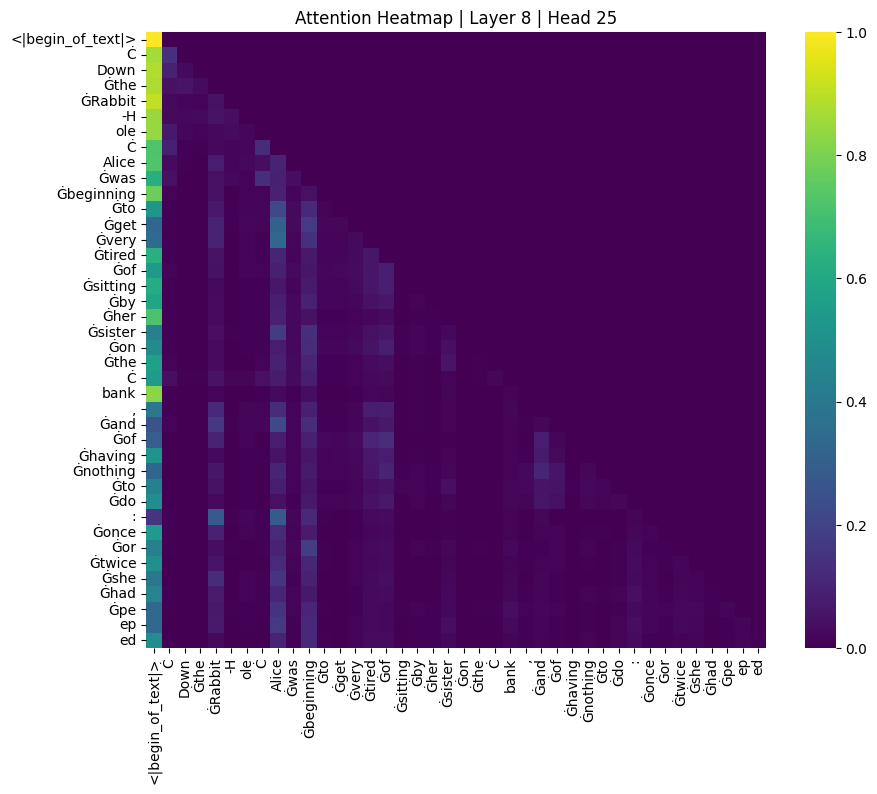

In [20]:
plot_attention(
    attentions,
    tokens,
    layer=8,
    head=25,
    max_tokens=40
)


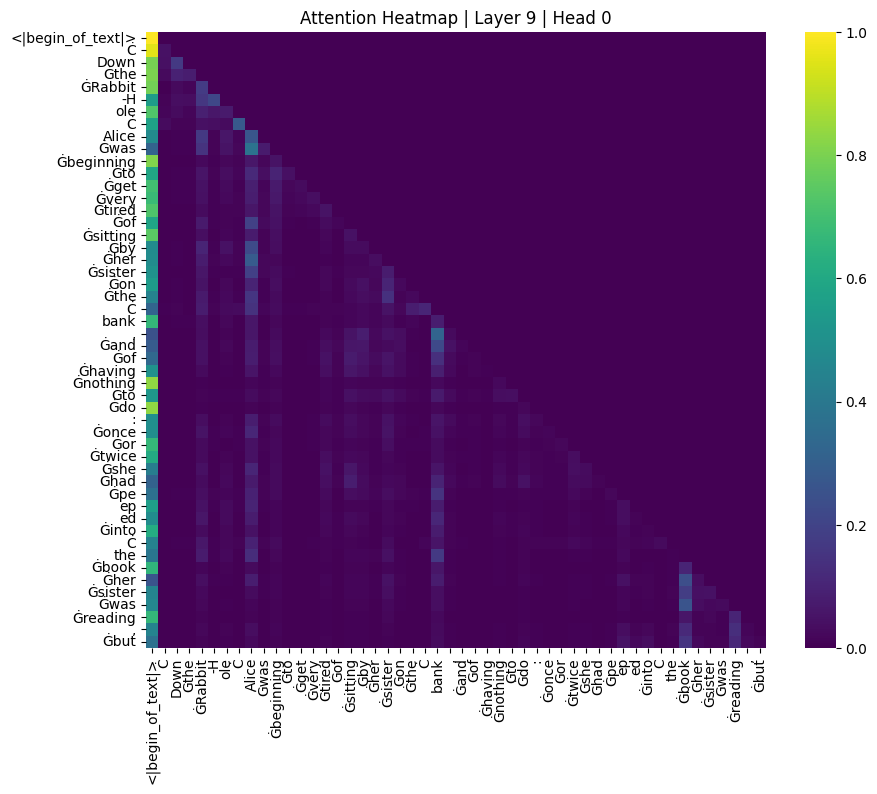

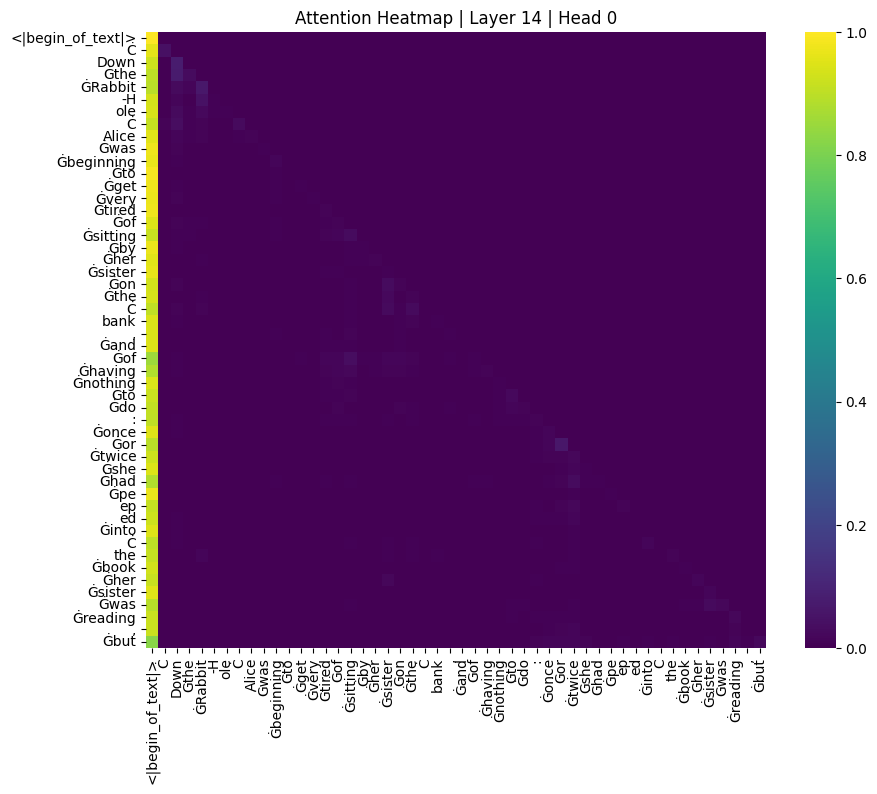

In [26]:
plot_attention(attentions, tokens, layer=9, head=0)
plot_attention(attentions, tokens, layer=14, head=0)


In [27]:
import numpy as np

def mean_attention_to_first_token(attentions, layer, head):
    attn = attentions[layer][0, head]
    return attn[:, 0].mean().item()

mean_attention_to_first_token(attentions, layer=15, head=5)


0.6103515625

In [28]:
def plot_mean_attention(attentions, tokens, layer=0, max_tokens=40):
    attn = attentions[layer][0].mean(dim=0).cpu().numpy()
    attn = attn[:max_tokens, :max_tokens]
    tok = tokens[:max_tokens]

    plt.figure(figsize=(10, 8))


    sns.heatmap(attn, xticklabels=tok, yticklabels=tok, cmap="cividis")

    plt.title(f"Mean Attention | Layer {layer}")
    plt.xticks(rotation=90)
    plt.show()


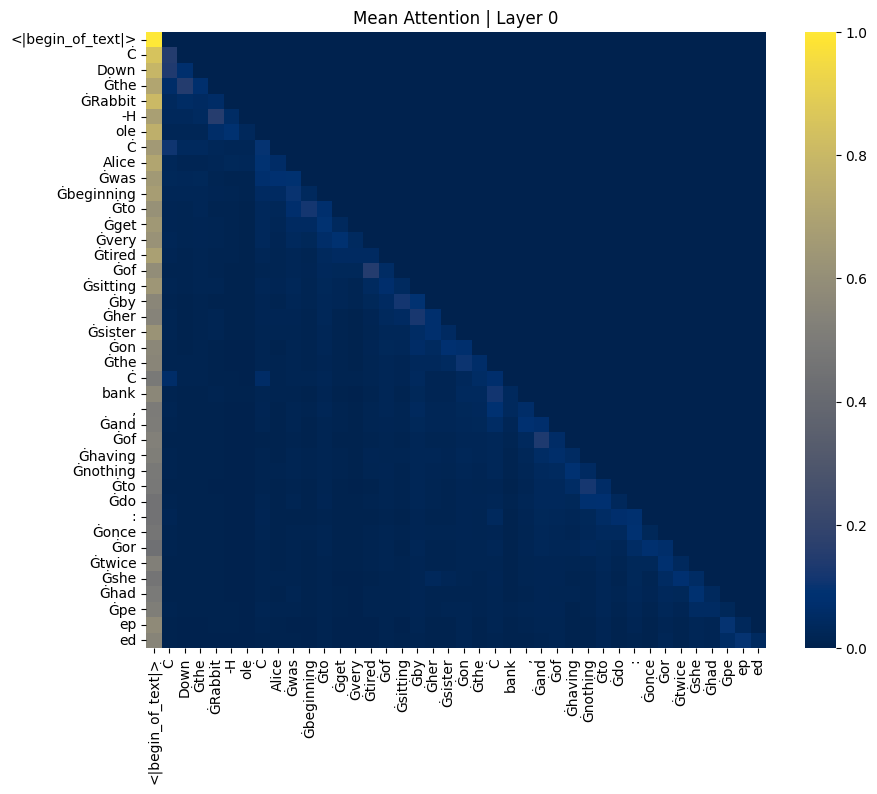

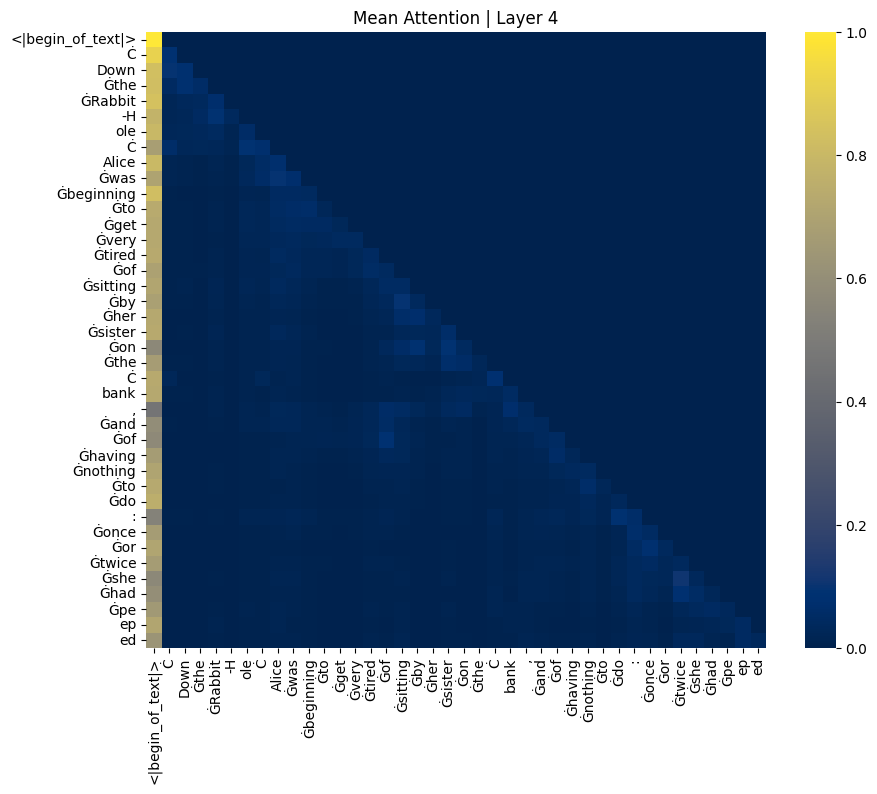

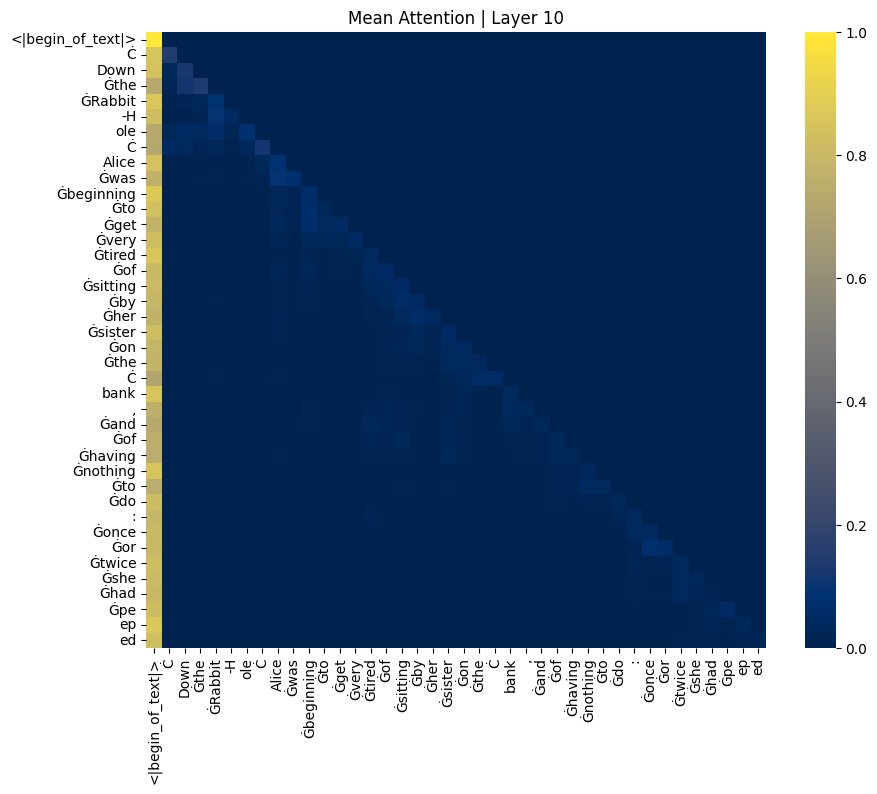

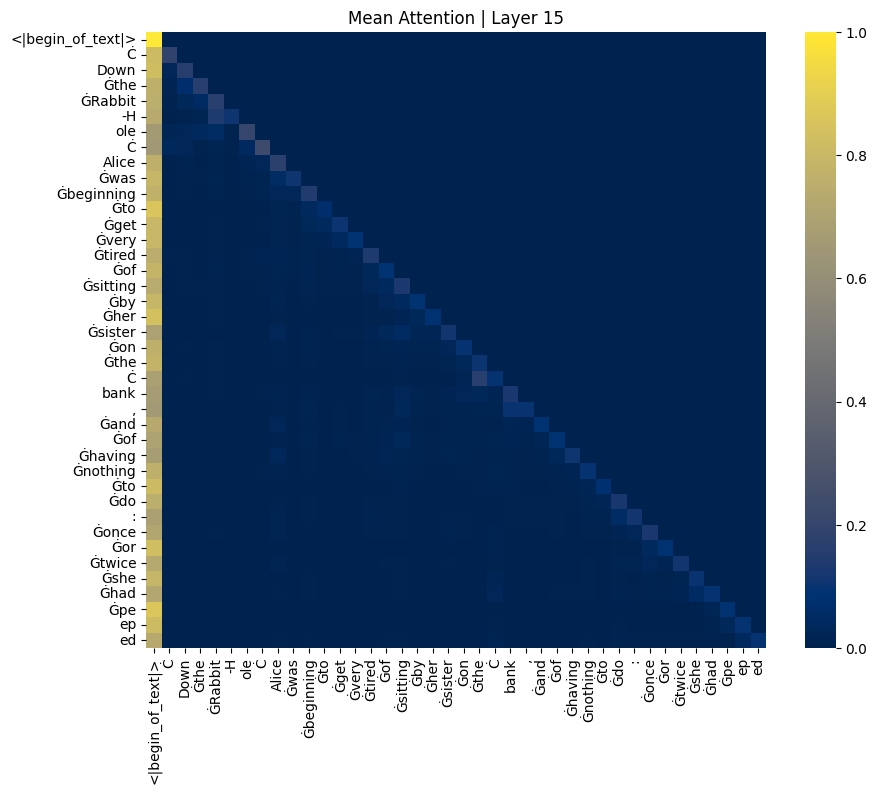

In [33]:
for layer in [0, 4, 10, 15]:
    plot_mean_attention(attentions, tokens, layer)


In [16]:
target_word = "CHAPTER"

# Trouver le token correspondant
for i, tok in enumerate(tokens):
    if target_word in tok:
        print(i, tok)


2 CHAPTER


In [35]:


def token_influence_by_layer(attentions, target_idx):
    influences = []

    for layer_attn in attentions:
        # layer_attn: [batch, heads, tokens, tokens]
        layer_attn = layer_attn[0]  # batch

        # moyenne sur les heads
        mean_attn = layer_attn.mean(dim=0)  # [tokens, tokens]

        # colonne correspondant au token cible
        influence = mean_attn[:, target_idx].mean().item()
        influences.append(influence)

    return influences


In [46]:
target_idx = 67
influences = token_influence_by_layer(attentions, target_idx)


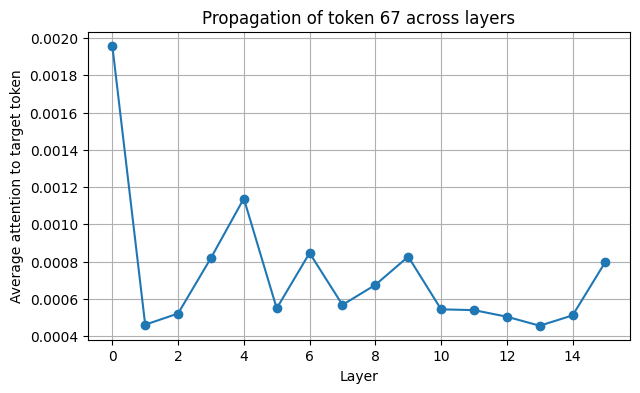

In [47]:

plt.figure(figsize=(7, 4))
plt.plot(influences, marker="o")
plt.xlabel("Layer")
plt.ylabel("Average attention to target token")
plt.title(f"Propagation of token {target_idx} across layers")
plt.grid(True)
plt.show()
